<a href="https://colab.research.google.com/github/LeoTungAnh/Morden-Computer-Vision-with-Pytorch-v2/blob/main/Reinforcement_Learning/CartPole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithm for Deep Q Learning
Initialize Q-network θ
Initialize target network θ⁻ = θ
Initialize replay buffer D

for each episode:
    reset environment → state s

    for each step:
        choose action a using ε-greedy

        take action → observe r, s', done

        store (s, a, r, s', done) in D

        sample minibatch from D

        compute target:
            if done:
                target = r
            else:
                target = r + γ * max Q_target(s', a')

        update θ using gradient descent

        every N steps:
            θ⁻ ← θ

        s ← s'

In [ ]:
%pip install "gym==0.26.2"
import gym
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from collections import namedtuple, deque
import torch.optim as optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 19.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827728 sha256=288040e5dc1b68a6058ff2b90bf74c5f26469ccfeb67b955687cc3fa797ddd03
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
env = gym.make('CartPole-v1')

In [ ]:
env.observation_space

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)

In [ ]:
state = env.reset()
state

(array([ 0.03374677, -0.02576848,  0.00920218,  0.01145922], dtype=float32),
 {})

In [ ]:
class DQNetwork(nn.Module):
  def __init__(self, state_size, hidden_size, action_size) -> None:
    super(DQNetwork, self).__init__()
    self.fc1 = nn.Linear(state_size,hidden_size)
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.fc3 = nn.Linear(hidden_size, action_size)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

# Pseudo code
```
state = env.reset()

  while True:

    q_values = model(state)        

    action = choose_action(q_values)

    next_state, reward, done, _ = env.step(action)

    # store transition
    D.append((state, action, reward, next_state, done))

    state = next_state
```



Using device: cuda


Text(0.5, 1.0, 'Scores over increasing episodes')

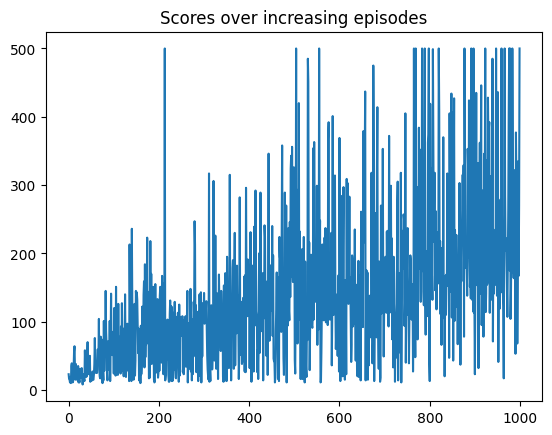

In [ ]:
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005
gamma = 0.9
D = []
batch_size = 32

dqn = DQNetwork(env.observation_space.shape[0], 128, env.action_space.n).to(device)
optimizer = optim.Adam(dqn.parameters(), lr=0.001)

eps = 1000
steps = 500
scores = []

for e in range(eps):
    current_state, _ = env.reset()
    score = 0

    for step in range(steps):
        trade_off = np.random.uniform(0, 1)

        if trade_off > epsilon:
            # Trust network
            dqn.eval()
            with torch.no_grad():
                state_tensor = torch.tensor(current_state, dtype=torch.float32, device=device).unsqueeze(0)
                action = torch.argmax(dqn(state_tensor), dim=1).item()
        else:
            # Take random action
            action = np.random.randint(0, env.action_space.n)

        # Get feedback from the env
        next_state, reward, terminated, truncated, _ = env.step(int(action))
        done = terminated or truncated

        score += reward

        # Collect data
        D.append([current_state, action, reward, next_state, int(done)])
        current_state = next_state

        if len(D) > batch_size:
            samples = random.sample(D, batch_size)
            current_states, actions, rewards, next_states, dones = zip(*samples)

            current_states = torch.tensor(np.array(current_states), dtype=torch.float32, device=device)
            actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
            rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
            next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
            dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

            dqn.train()

            # Current Q values
            cur_Q = dqn(current_states).gather(1, actions)

            # Target Q values
            with torch.no_grad():
                next_Q = dqn(next_states).max(1)[0].unsqueeze(1)
                target_Q = rewards + gamma * next_Q * (1 - dones)

            # Loss
            loss = F.mse_loss(cur_Q, target_Q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * e)

        if done:
            break

    scores.append(score)
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(scores)
plt.title('Scores over increasing episodes')